# **KLUE RE 전체 실험 파이프라인**

# **0) 프로젝트 개요**

**[프로젝트 정보]**

| 항목 | 내용 |
|---|---|
| 목표 | KLUE RE 데이터셋을 활용하여 문장 내 subject/object entity 간 관계를 추출하는 모델 학습 및 성능 개선 방법 탐구 |
| 데이터셋 | Hugging Face `load_dataset("klue", "re")` |
| Task | Relation Extraction |
| 최종 평가 지표 | `Micro-F1 (except no_relation)`, `AUPRC (30 classes)` |


---

**[전체 실험 흐름]**

| 단계 | 수행 내용 | 상세 내용 |
|---|---|--|
| 1 | 데이터셋 다운로드 및 로드 | |
| 2 | EDA 수행 | 결측/중복 데이터 확인, 분포 분석, EDA 기반 실험 가설 도출 |
| 3 | 데이터셋 구성 | Data Split / Input Format 실험 및 데이터셋 구조 확정 |
| 4 | Architecture 설계 및 구현 | 구조 성능 비교 (`CLS`, `entity_start`, `entity_start_end`) |
| 5 | LLM 모델 선정 | 성능·비용·효율 비교, 최적 모델 선정 |
| 6 | 성능 검토 | relation F1, type pair, confusion matrix, 오답 분석 |
| 7 | 성능 개선 | threshold, calibration, 추가 실험 수행 |

---

**[전체 실험 흐름]**
*(5. 모델 선정 이전 단계 공통 조건)*

| 항목 | 설정 |
|---|---|
| Baseline PLM | `klue/roberta-large` |
| 선정 이유 | KLUE 벤치마크 및 선행 프로젝트에서 안정적인 RE 성능 확인 |
| Learning Rate | `3e-5` |
| Epoch | `5` |
| Warmup Ratio | `10%` |
| Batch Size | `8` |
| Optimizer | `AdamW` |
| Scheduler | Linear Warmup → Linear Decay |

---

**[최종 실험 결과]**

| 구분 | 최종 선택 |
|---|---|
| Data Split | `detailed_stratified` |
| Input Format | `typed_entity_marker_punct_question` |
| Architecture | `entity_start` |
| PLM | `klue/roberta-large` |
| 성능 개선 | `Temperature Calibration (T=1.6)` |

---

**[최종 성능]**

| 조건 | test_micro_f1 | test_auprc |
|---|---:|---:|
| Baseline | `73.04` | `77.26` |
| + Threshold tuning | `72.76` | `77.25` |
| + Temperature Calibration | `73.03` | `77.66` |

---

**[실험 환경]**

| 항목 | 설정 |
|---|---|
| GPU | NVIDIA GeForce RTX 3060 (12GB VRAM) |
| CUDA | 13.1 |
| Driver | 591.86 |
| Framework | PyTorch + Hugging Face Transformers |
| Dataset Library | Hugging Face Datasets |

In [27]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src' / 'data_loader.py').exists() and (path / 'configs').exists():
            return path
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. notebooks 폴더 또는 프로젝트 루트에서 실행해 주세요.')

ROOT = find_project_root()
if str(ROOT / 'src') not in sys.path:
    sys.path.append(str(ROOT / 'src'))

## **1) 데이터셋 다운로드 및 로드**

- Hugging Face `load_dataset("klue", "re")` 사용
- 원본 데이터는 `data/raw/klue_re`에 저장

In [13]:
import importlib
import data_loader

# Jupyter 커널에 이전 data_loader가 캐시되어 있을 수 있으므로 reload
importlib.reload(data_loader)

dataset, label_names, label2id, id2label = data_loader.load_klue_re()
test_split_name = 'validation' if 'validation' in dataset else 'test'

summary = pd.DataFrame({
    'split': ['train', 'test'],
    'num_rows': [len(dataset['train']), len(dataset[test_split_name])],
})
display(summary)


,split,num_rows
0,train,32470
1,test,7765


In [14]:
print('num_labels:', len(label_names), end='\n\n')
print('labels:', label_names)

num_labels: 30

labels: ['no_relation', 'org:dissolved', 'org:founded', 'org:place_of_headquarters', 'org:alternate_names', 'org:member_of', 'org:members', 'org:political/religious_affiliation', 'org:product', 'org:founded_by', 'org:top_members/employees', 'org:number_of_employees/members', 'per:date_of_birth', 'per:date_of_death', 'per:place_of_birth', 'per:place_of_death', 'per:place_of_residence', 'per:origin', 'per:employee_of', 'per:schools_attended', 'per:alternate_names', 'per:parents', 'per:children', 'per:siblings', 'per:spouse', 'per:other_family', 'per:colleagues', 'per:product', 'per:religion', 'per:title']


## **2) EDA 수행**

- 자세한 EDA는 `notebooks/eda.ipynb`에 작성

- **EDA 요약**

    - **`EDA Insight 1`** 중복 데이터 제거 여부 성능 비교 실험 필요
        - 데이터셋에 완전 중복(문장, sbj, obj, label 동일) 데이터가 존재하지만 비중이 매우 작음
        - 중복 데이터 제거가 성능 개선에 영향을 미치는지 7. `성능 개선` 단계에서 비교 실험 수행

    - **`EDA Insight 2`** Typed Marker 실험 필요성 도출
        - sbj-object type 조합과 label 간 연관성을 확인하였으며, type 정보 제공이 label 예측에 도움이 될 것으로 판단
        - Marker 삽입 여부, Marker 종류, type 제공 여부에 따른 다양한 실험 수행 (3.2)

    - **`EDA Insight 3`** `{label}-{subject_type}-{object_type}` 기반 Data Split 실험 수행
        - label 분포가 `no_relation`에 편향되어 있으나, sbj-object 조합까지 고려할 경우 학습 및 평가 데이터 편향 완화 가능할 것으로 판단
        - {label}-{subject_type}-{object_type} 정보 엮어 층화추출하는 `Detailed Stratified Split` 전략 도출 (3.1)

## **3) 데이터셋 구성**

### **3.1) Data Split 전략 (Detailed Stratified Split)**

-  **`EDA Insight 3`** 에 근거하여, Data Split 방식별 학습 및 평가 안정성 확인
    - `random split`: 비율을 고려하지 않고 무작위로 분할
    - `label stratified split`: 정답 라벨 비율만 맞춰 분할
    - `detailed stratified split`: `{label}-{subject_type}-{object_type}` 정보 엮어 비율 맞춰 분할

In [4]:
!python ../src/split_experiments.py

[SKIP] already done: split_random
[SKIP] already done: split_stratified
[SKIP] already done: split_detailed_stratified
수행할 새 split 실험이 없습니다. 모든 split 실험이 이미 완료되었습니다.


In [15]:
split_path = ROOT / 'outputs' / 'split_experiments.csv'
if split_path.exists():
    split_results = pd.read_csv(split_path)
    print('[Split experiment results]')
    display_cols = [
        'split_strategy',
        'val_micro_f1', 'test_micro_f1', 'val_auprc', 'val_macro_f1',
        'val_macro_f1', 'test_macro_f1',
    ]
    for col in display_cols:
        if col not in split_results.columns:
            split_results[col] = None
    display(split_results[display_cols].sort_values('val_micro_f1', ascending=False, na_position='last'))
else:
    print('outputs/split_experiments.csv not found. Run python src/split_experiments.py first.')


[Split experiment results]


,split_strategy,val_micro_f1,test_micro_f1,val_auprc,val_macro_f1,val_macro_f1,test_macro_f1
0,random,82.460622,58.752887,73.389583,65.473546,65.473546,52.086281
1,label_stratified,82.067645,60.392397,75.745934,66.736341,66.736341,54.508037
2,detailed_stratified,81.827843,61.283390,75.919013,67.932240,67.932240,54.301612


### **결과 해석**

- `random split` -> `val_micro_f1`에서 가장 높은 점수 보임
- `detailed_stratified split` -> `test_micro_f1`, `val_auprc`, `val_auprc`에서 가장 높은 성능 보임


- 특히 `detailed_stratified split`은 `macro_f1` 기준에서도 높은 성능 보임
    - `macro_f1`: 라벨별 F1 평균 계산 평가 지표. no_relation에 편향된 데이터셋 내, 희귀 관계 고려 가능
    - -> relation 전반에서 균형적인 예측이 가능하다고 판단할 수 있음

- **최종 성능과 분포 안정성을 함께 고려하여 `detailed_stratified split` 방식을 기본 split 전략으로 선정함**


### **3.2) Input Format 전략**

-  **`Marker format` 전략**

    -  Relation Extraction(RE)은 entity의 이름(name), 위치(span), 유형(type) 정보를 입력에 어떻게 표현하는지에 따라 성능 차이가 발생할 수 있음[6]

    - 또한 **`EDA Insight 2`** 근거로 부터 entity 정보를 문장 내부에 명시하는  비교 실험 수행

- **`Prompt format` 전략**

    - subject/object 정보를 자연어 형태로 추가 제공할 경우, 모델이 entity type 및 문맥 정보를 함께 활용할 수 있을 것으로 판단

    - [2], [3], [7] 를 참고하되 prompt 내부에는 정답 관계(label) 이름이나 관계 의미를 직접 포함하지 않도록 구성하여 label leakage를 방지함
        - (예: @ 사람 이순신 @은 조선의 # ^ 직업 ^ 무신 # 이다. -> “직업 관계”라는 정답 힌트가 들어가 있음)

#### **3.2.1) Marker Format 비교 [6]**

| Format | 입력 예시 | 목적 |
|---|---|---|
| `entity_marker` | `[E1]이순신[/E1]은 조선 중기의 [E2]무신[/E2]이다.` | entity 위치(span) 정보를 명시적으로 제공 |
| `entity_marker_punct` | `@ 이순신 @은 조선 중기의 # 무신 #이다.` | 특수 기호를 활용하여 entity 경계를 강조 |
| `typed_entity_marker` | `<S:PERSON>이순신</S:PERSON>은 조선 중기의 <O:OCCUPATION>무신</O:OCCUPATION>이다.` | entity 위치와 함께 entity type 정보를 제공 |
| `typed_entity_marker_punct` | `@ * person * 이순신 @은 조선 중기의 # ^ occupation ^ 무신 #이다.` | type 정보와 marker 강조를 동시에 적용 |


In [6]:
!python ../src/preprocess_experiments.py

[SKIP] already done: preprocess_prompt_s_sep_o
[SKIP] already done: preprocess_prompt_s_and_o
[SKIP] already done: preprocess_prompt_question
[SKIP] already done: preprocess_prompt_type_prompt
[SKIP] already done: preprocess_entity_marker
[SKIP] already done: preprocess_entity_marker_punct
[SKIP] already done: preprocess_typed_entity_marker
[SKIP] already done: preprocess_typed_entity_marker_punct
[SKIP] already done: preprocess_entity_marker_punct_s_and_o
[SKIP] already done: preprocess_entity_marker_punct_question
[SKIP] already done: preprocess_typed_entity_marker_punct_s_and_o
[SKIP] already done: preprocess_typed_entity_marker_punct_question
수행할 새 실험이 없습니다. 모든 preprocess 실험이 이미 완료되었습니다.


In [16]:
print('[Marker_format_experiments Result]')
Marker_format_experiments = ['preprocess_entity_marker', 'preprocess_entity_marker_punct', 'preprocess_typed_entity_marker', 'preprocess_typed_entity_marker_punct']

preprocess_path = ROOT / 'outputs' / 'preprocess_experiments.csv'
if preprocess_path.exists():
    preprocess_results = pd.read_csv(preprocess_path)
    current_preprocess_results = preprocess_results[
        preprocess_results['experiment_name'].isin(Marker_format_experiments)
    ].copy()
    display_cols = [
        'experiment_name', 'input_style',
        'val_micro_f1', 'val_auprc',
        'test_micro_f1', 'test_auprc'
    ]
    for col in display_cols:
        if col not in current_preprocess_results.columns:
            current_preprocess_results[col] = None
    display(current_preprocess_results[display_cols].sort_values('val_micro_f1', ascending=False, na_position='last'))
else:
    print('outputs/preprocess_experiments.csv not found. Run python src/preprocess_experiments.py first.')


[Marker_format_experiments Result]


,experiment_name,input_style,val_micro_f1,val_auprc,test_micro_f1,test_auprc
5,preprocess_entity_marker_punct,entity_marker_punct,83.807905,79.367694,64.685782,67.150286
7,preprocess_typed_entity_marker_punct,typed_entity_marker_punct,83.319185,78.308480,66.121973,68.100440
6,preprocess_typed_entity_marker,typed_entity_marker,83.206107,77.389301,64.001221,66.089569
4,preprocess_entity_marker,entity_marker,82.147422,74.324718,59.066565,59.599100


#### **3.2.2) Prompt Format 비교 [7]**

| Format | 입력 예시 | 목적 |
|---|---|---|
| `s_sep_o` | `이순신 [SEP] 무신 [SEP] 이순신은 조선 중기의 무신이다.` | subject와 object를 문장 외부 입력으로 분리하여 관계 추론 단서를 제공 |
| `s_and_o` | `이순신과 무신의 관계 [SEP] 이순신은 조선 중기의 무신이다.` | 관계 추론 목적을 자연어 형태로 명시 |
| `question` | `이순신은 조선 중기의 무신이다. [SEP] 이순신과 무신의 관계는 무엇입니까?` | 질의응답 형태로 relation prediction 유도 |
| `type_prompt` | `이순신은 조선 중기의 무신이다. [SEP] subject는 person 유형의 개체이고 object는 occupation 유형의 개체이다. 문맥을 바탕으로 두 개체 사이의 관계를 분류하시오.` | 자연어 기반으로 entity type 정보를 함께 제공 |


In [17]:
print('[Prompt_format_experiments Result]')
Prompt_format_experiments = ['preprocess_prompt_s_sep_o', 'preprocess_prompt_s_and_o', 'preprocess_prompt_question', 'preprocess_prompt_type_prompt']

preprocess_path = ROOT / 'outputs' / 'preprocess_experiments.csv'
if preprocess_path.exists():
    preprocess_results = pd.read_csv(preprocess_path)
    current_preprocess_results = preprocess_results[
        preprocess_results['experiment_name'].isin(Prompt_format_experiments)
    ].copy()
    display_cols = [
        'experiment_name', 'input_style',
        'val_micro_f1', 'val_auprc',
        'test_micro_f1', 'test_auprc'
    ]
    for col in display_cols:
        if col not in current_preprocess_results.columns:
            current_preprocess_results[col] = None
    display(current_preprocess_results[display_cols].sort_values('val_micro_f1', ascending=False, na_position='last'))
else:
    print('outputs/preprocess_experiments.csv not found. Run python src/preprocess_experiments.py first.')


[Prompt_format_experiments Result]


,experiment_name,input_style,val_micro_f1,val_auprc,test_micro_f1,test_auprc
1,preprocess_prompt_s_and_o,s_and_o,82.849829,76.279839,65.306748,66.311989
2,preprocess_prompt_question,question,82.485635,75.766284,65.470446,67.130773
0,preprocess_prompt_s_sep_o,s_sep_o,81.958872,74.962748,62.306157,63.286992
3,preprocess_prompt_type_prompt,type_prompt,75.318607,60.472333,40.719640,38.546031


#### **3.2.3) Entity Marker + Prompt 조합 실험**

- `Marker format` 상위 2개와 `Prompt format` 상위 2개를 조합하여 결합 실험 수행

| 구분 | 선택 방식 |
|---|---|
| Marker 상위 방식 | `typed_entity_marker_punct`, `entity_marker_punct` |
| Prompt 상위 방식 | `question`, `s_and_o` |

---

### 조합 실험 구성

| Format | 입력 예시 | 특징 |
|---|---|---|
| `entity_marker_punct_s_and_o` | `이순신과 무신의 관계 [SEP] @ 이순신 @은 조선 중기의 # 무신 #이다.` | marker 기반 entity 강조 + 자연어 관계 힌트 |
| `entity_marker_punct_question` | `@ 이순신 @은 조선 중기의 # 무신 #이다. [SEP] 이순신과 무신의 관계는 무엇입니까?` | marker 기반 entity 강조 + QA 형태 관계 추론 |
| `typed_entity_marker_punct_s_and_o` | `이순신과 무신의 관계 [SEP] @ * person * 이순신 @은 조선 중기의 # ^ occupation ^ 무신 #이다.` | entity type + marker + 자연어 관계 힌트 |
| `typed_entity_marker_punct_question` | `@ * person * 이순신 @은 조선 중기의 # ^ occupation ^ 무신 #이다. [SEP] 이순신과 무신의 관계는 무엇입니까?` | entity type + marker + QA 형태 관계 추론 |

---

In [18]:
print('[Entity_marker_prompt_experiments Result]')
Entity_marker_prompt_experiments = [
    'preprocess_entity_marker_punct_s_and_o',
    'preprocess_entity_marker_punct_question',
    'preprocess_typed_entity_marker_punct_s_and_o',
    'preprocess_typed_entity_marker_punct_question',
]

preprocess_path = ROOT / 'outputs' / 'preprocess_experiments.csv'
if preprocess_path.exists():
    preprocess_results = pd.read_csv(preprocess_path)
    current_preprocess_results = preprocess_results[
        preprocess_results['experiment_name'].isin(Entity_marker_prompt_experiments)
    ].copy()
    display_cols = [
        'input_style',
        'val_micro_f1', 'val_auprc',
        'test_micro_f1', 'test_auprc'
    ]
    for col in display_cols:
        if col not in current_preprocess_results.columns:
            current_preprocess_results[col] = None
    display(current_preprocess_results[display_cols].sort_values('val_micro_f1', ascending=False, na_position='last'))
else:
    print('outputs/preprocess_experiments.csv not found. Run python src/preprocess_experiments.py first.')


[Entity_marker_prompt_experiments Result]


,input_style,val_micro_f1,val_auprc,test_micro_f1,test_auprc
10,typed_entity_marker_punct_s_and_o,84.434062,79.407620,67.278471,68.555850
11,typed_entity_marker_punct_question,84.192659,79.687540,67.735592,71.445734
9,entity_marker_punct_question,83.404075,78.283125,67.220903,69.508746
8,entity_marker_punct_s_and_o,82.507412,76.292882,65.796580,67.267119


### **결과 해석 (Input Format)**
- `typed_entity_marker_punct_question` -> `val_micro_f1`제외, 나머지 평가 지표에서 가장 높은 성능 기록함.

    - type 정보와 특수기호를 삽입하며 자연어 형태로 질의하는 입력 포맷이 가장 관계 예측에 도움이 되는 것으로 판단됨.


- **이후 Architecture 및 모델 비교 실험에서는 `typed_entity_marker_punct_question`을 기본 Input Format으로 선정함**

### **3.3) Augmentation 적용 여부**

- 참고한 선행 실험에서는 데이터 불균형 및 일반화 성능 개선을 위해 다양한 데이터 증강 기법을 적용함 [2][3][4]
    - EDA / AEDA
    - Sampling (Under / Over Sampling)
    - Back Translation
    - Entity 교체 기반 Target Augmentation

- 그러나 대부분의 실험에서 데이터 증강에 따른 **일관된 성능 향상을 확인하지 못함**
    - 일부 조건에서는 성능 하락 발생
    - Back Translation은 특정 번역 조합에서만 제한적인 개선 확인
    - 전체 데이터에 일괄 적용하는 증강보다 **오류 유형 기반 접근이 더 중요하다**는 인사이트 도출

- 이를 바탕으로 데이터 증강을 우선 적용하지 않고,
    - Input Format 최적화
    - Architecture 설계
    - PLM 모델 비교
    - Hyperparameter 조정
    중심으로 성능 개선 실험 수행

- 이후 성능 검토 단계에서 relation별 성능과 confusion matrix를 분석한 뒤 필요한 경우에만 데이터 증강 적용 여부를 재검토 예정

- 향후 적용 가능한 증강 방향
    - **`Back Translation`**
        - 일부 번역 조합에서만 성능 개선 관찰[4]

    - **`Entity Swap Augmentation`**
        - 동일 type 내 entity 어휘 교체 후 relation 유지

    - **`Hard Example Augmentation`**
        - 성능 검토 단계의 오답 사례 분석(confusion matrix) 결과를 기반으로 선택적 증강 수행
  
    - **`LLM 기반 Controlled Paraphrase`**
        - entity span과 relation을 유지한 문장 재생성

## **4) Architecture 설계 및 구현**

- Input Format은 `typed_entity_marker_punct_question`으로 고정하여 실험 수행 (3.2.3 결과 기반)
- 선행 연구 [5]를 참고하여 동일한 입력 조건에서 **relation representation 추출 방식만 변경**하여 비교

---

**[비교 Architecture]**

| Architecture | 구조 | 특징 |
|---|---|---|
| `cls` | `[CLS]` representation → Classification | 문장 전체 표현 기반 baseline |
| `entity_start` | `[CLS] + subject/object start marker` | entity 시작 위치 정보를 직접 활용 |
| `entity_start_end` | `[CLS] + subject/object start/end marker` | entity 시작·종료 위치 정보를 함께 활용 |

---

**[공통 학습 설정]**

| 항목 | 설정 |
|---|---|
| PLM | `klue/roberta-large` |
| Learning Rate | `3e-5` |
| Epoch | `5` |
| Batch Size | `8` |
| Warmup Ratio | `0.1` |
| Optimizer | `AdamW` |
| Scheduler | Linear Warmup → Linear Decay |

※ 선행 연구 [5]의 학습 파라미터를 참고하되, GPU 환경 제약에 따라 `per_device_train_batch_size`, `gradient_accumulation_steps`를 조정함

---

In [10]:
import subprocess
import sys

architecture_path = ROOT / 'outputs' / 'architecture_experiments.csv'
required_architecture_experiments = {
    'architecture_cls',
    'architecture_entity_start',
    'architecture_entity_start_end',
}

if architecture_path.exists():
    architecture_done = pd.read_csv(architecture_path)
    done_names = set(architecture_done.get('experiment_name', pd.Series(dtype=str)).dropna().astype(str))
else:
    done_names = set()

missing = sorted(required_architecture_experiments - done_names)
if not missing:
    print('All required architecture experiments are already completed. Skip training.')
else:
    print('Missing architecture experiments:', missing)
    cmd = [sys.executable, str(ROOT / 'src' / 'architecture_experiments.py')]
    subprocess.run(cmd, cwd=ROOT, check=True)


All required architecture experiments are already completed. Skip training.


In [30]:
architecture_path = ROOT / 'outputs' / 'architecture_experiments.csv'
active_architecture_experiments = [
    'architecture_cls',
    'architecture_entity_start',
    'architecture_entity_start_end',
]

if architecture_path.exists():
    architecture_results = pd.read_csv(architecture_path)
    architecture_results = architecture_results[
        architecture_results['experiment_name'].isin(active_architecture_experiments)
    ].copy()
    display_cols = [
        'architecture',
        'val_micro_f1', 'val_auprc', 'test_micro_f1', 'test_auprc'
    ]
    for col in display_cols:
        if col not in architecture_results.columns:
            architecture_results[col] = None
    display(architecture_results[display_cols].sort_values('val_micro_f1', ascending=False, na_position='last'))
else:
    print('출력 파일이 없습니다. 먼저 python src/architecture_experiments.py를 실행하세요.')


,architecture,val_micro_f1,val_auprc,test_micro_f1,test_auprc
0,cls,86.223942,84.839216,71.414791,76.923411
1,entity_start,86.034000,84.383554,73.036897,77.264496
2,entity_start_end,86.005199,84.765159,72.440427,78.971265


### **실험 결과**

- `entity_start` → `test_micro_f1` 최고 (`73.04`)
- `entity_start_end` → `test_auprc` 최고 (`78.97`)
- `cls` → validation 성능은 높았으나 test 일반화 성능은 상대적으로 낮음

→ 즉, entity 정보 활용 자체는 유효했으나, end marker 추가가 항상 최종 분류 성능(F1) 향상으로 이어지지는 않음을 확인함.

→ **이후 실험은 KLUE 공식 주요 지표인 `Micro-F1` 기준 가장 높은 성능을 보인 `entity_start` 구조로 진행함.**

## **5) LLM 모델 선정**

- 동일 split과 input format 조건에서 모델만 변경하여 성능 비교 수행
- 모델 구조 변화 없이 언어모델 자체의 표현 능력이 RE 성능에 미치는 영향 확인
- 성능과 학습 비용을 함께 고려하여 최종 모델 선정

**비교 모델**

- **(baseline)`klue/roberta-large`**
    - KLUE 데이터 기반 학습 모델 중 높은 성능이 보고된 대표 모델

- **`klue/roberta-base`**
    - KLUE 벤치마크 기반 한국어 특화 RoBERTa 모델, 비교적 낮은 학습 비용
    - **선정이유: baseline 모델과 파라미터 차이에 따른 비용/성능 trade-off 확인 목적**

- **`klue/bert-base`**
    - 한국어 특화 BERT encoder 기반 모델, RoBERTa 대비 tokenizer 차이 존재
    - **선정이유: RoBERTa vs BERT 비교(RoBERTa 대비 pretraining 전략 차이에 따른 성능 비교 목적)**

- **`studio-ousia/luke-large`**[10]
    - Entity-aware attention 기반 언어모델
    - entity 정보를 직접 표현하도록 설계되어 RE task와 높은 구조적 연관성 보유
    - **선정이유: TACRED SOTA 모델 선정, 그 외 Relation Extraction 벤치마크에서 우수 성능 사례 보고**

### **평가 기준**

- **성능**
    - `test_micro_f1`
    - `test_auprc`
    - `test_macro_f1`

- **비용**
    - `elapsed_sec`

- **효율**
    - `test_micro_f1 / elapsed_min`

- 최종 모델은 성능, 학습 시간, GPU 환경 제약을 함께 고려하여 선정

In [27]:
import subprocess
import sys

model_path = ROOT / 'outputs' / 'model_experiments.csv'
required_model_experiments = {
    'model_roberta_base',
    'model_roberta_large',
    'model_bert_base',
    'model_luke_large',
}

if model_path.exists():
    model_done = pd.read_csv(model_path)
    done_names = set(model_done.get('experiment_name', pd.Series(dtype=str)).dropna().astype(str))
else:
    done_names = set()

missing = sorted(required_model_experiments - done_names)
if not missing:
    print('All required model experiments are already completed. Skip training.')
else:
    print('Missing model experiments:', missing)
    cmd = [sys.executable, str(ROOT / 'src' / 'model_experiments.py')]
    subprocess.run(cmd, cwd=ROOT, check=True)


All required model experiments are already completed. Skip training.


In [36]:
model_path = ROOT / 'outputs' / 'model_experiments.csv'
active_model_experiments = [
    'model_roberta_base',
    'model_roberta_large',
    'model_bert_base',
    'model_luke_large',
]

if model_path.exists():
    model_results = pd.read_csv(model_path)
    model_results = model_results[
        model_results['experiment_name'].isin(active_model_experiments)
    ].copy()
    display_cols = [
        'model',
        'val_accuracy', 'val_micro_f1', 'val_auprc',
        'test_accuracy', 'test_micro_f1', 'test_auprc'
    ]
    for col in display_cols:
        if col not in model_results.columns:
            model_results[col] = None
    print('[모델별 실험 결과]')
    display(model_results[display_cols].sort_values('val_micro_f1', ascending=False, na_position='last'))
else:
    model_results = pd.DataFrame()
    print('outputs/model_experiments.csv not found. Run python src/model_experiments.py first.')


# 모델별 성능/비용/효율
model_results["elapsed_min"] = model_results["elapsed_sec"] / 60
model_results["efficiency"] = model_results["test_micro_f1"] / model_results["elapsed_min"]

display_cols = [
    "model",
    "test_micro_f1",
    "test_auprc",
    "elapsed_min",
    "efficiency",
]

print('\n[모델별 성능/비용/효율 비교]')
display(
    model_results[display_cols]
    .sort_values("test_micro_f1", ascending=False)
)

[모델별 실험 결과]


,model,val_accuracy,val_micro_f1,val_auprc,test_accuracy,test_micro_f1,test_auprc
3,klue/roberta-large,84.293194,86.005199,84.765159,81.236317,72.440427,78.971265
0,klue/roberta-base,83.246073,85.394681,82.909056,76.497102,67.604772,73.305490
1,klue/bert-base,82.784108,84.761701,82.533643,76.651642,66.938392,72.188998
2,studio-ousia/luke-large,71.820142,73.406397,55.588312,59.755312,45.232558,30.921298



[모델별 성능/비용/효율 비교]


,model,test_micro_f1,test_auprc,elapsed_min,efficiency
3,klue/roberta-large,72.440427,78.971265,37.199500,1.947349
0,klue/roberta-base,67.604772,73.305490,31.954667,2.115646
1,klue/bert-base,66.938392,72.188998,17.559333,3.812126
2,studio-ousia/luke-large,45.232558,30.921298,47.755833,0.947163


### **실험 결과**

- `roberta-large` → `test_micro_f1`, `test_auprc` 모두 최고 (`72.44`, `78.97`)
- `roberta-base` → 성능은 다소 낮았으나 비용/효율 확보
- `bert-base` → 가장 높은 시간/효율을 보였으나 절대 성능은 낮음
- `LUKE-large` → 현재 입력 구조에서는 성능 이점을 확인하지 못함

→ 즉, 모델 구조 차이에 따른 성능 차이가 크게 나타났으며, 본 실험에서는 RoBERTa 계열이 가장 안정적인 RE 성능을 보였음.

→ **최종적으로 성능과 계산 비용을 함께 고려하여 `klue/roberta-large`를 최종 모델로 선정함.**


### **성능개선 Insight**

- **`Insight 1` - LUKE 제외, 각 모델별 장점을 기반으로 `ensemble` 실험 수행 가능**
- **`Insight 2` - `loss 조정`, `relation별 오류 기반 개선` 실험 수행 가능**

## **6) 성능 검토 및 개선 방향 도출**

- 최종 선정 모델(roberta-large + entity_start + typed_entity_marker_punct_question) 기준으로 오류 유형을 분석하고 성능 개선 방향을 도출함

- **분석 항목**

    - `Relation별 F1`→ relation별 precision, recall, F1을 확인하여 성능이 낮은 label 파악
    - `Entity Type Pair별 성능` → 특정 type 조합 취약 구간 확인
    - `Confusion Matrix` → relation 간 혼동 패턴 확인
    - `오답 사례 분석` → 실제 오류 원인 및 개선 방향 도출

- **실행 분석**
    - entity type pair별 성능: `type_pair_scores.csv`, `label_type_pair_scores.csv`
    - confusion matrix: `confusion_matrix.csv`, `confusion_matrix.png`
    - 오답 사례 분석: `wrong_predictions.csv`, `high_confidence_errors.csv`


In [28]:
!python ../src/error_analysis.py --config ../configs/model_roberta_large.yaml --split test --model_dir ../outputs/architecture_entity_start

^C



Loading weights: 100%|##########| 389/389 [00:00<00:00, 13455.03it/s]
[transformers] RobertaModel LOAD REPORT from: klue/roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable t

..\outputs\architecture_entity_start\error_analysis_test


[LOAD] Existing error analysis files found. Skip error_analysis.py.
[LOAD] Existing performance review files found. Skip performance_review.py.

[1] Relation F1 ascending


,label_name,precision,recall,f1-score,support
16,per:place_of_residence,0.489583,0.379032,0.427273,124.0
25,per:other_family,0.600000,0.352941,0.444444,34.0
26,per:colleagues,0.629213,0.509091,0.562814,220.0
6,org:members,0.594828,0.565574,0.579832,122.0
5,org:member_of,0.561404,0.615385,0.587156,104.0
3,org:place_of_headquarters,0.572614,0.711340,0.634483,194.0
28,per:religion,0.777778,0.538462,0.636364,13.0
12,per:date_of_birth,0.600000,0.750000,0.666667,12.0
19,per:schools_attended,0.700000,0.636364,0.666667,11.0
18,per:employee_of,0.595808,0.822314,0.690972,242.0



[2] Entity type pair performance


,type_pair,total,correct,accuracy,avg_confidence
0,PER-LOC,555,387,0.697297,0.860535
1,ORG-LOC,649,460,0.708783,0.904320
2,PER-PER,853,650,0.762016,0.911935
3,PER-ORG,383,295,0.770235,0.936901
4,ORG-POH,1501,1164,0.775483,0.922230
5,ORG-PER,285,231,0.810526,0.940335
6,ORG-ORG,664,559,0.841867,0.950523
7,PER-POH,1670,1424,0.852695,0.950669
8,PER-NOH,136,119,0.875000,0.960295
9,ORG-NOH,279,258,0.924731,0.967005



[3] Confusion Matrix


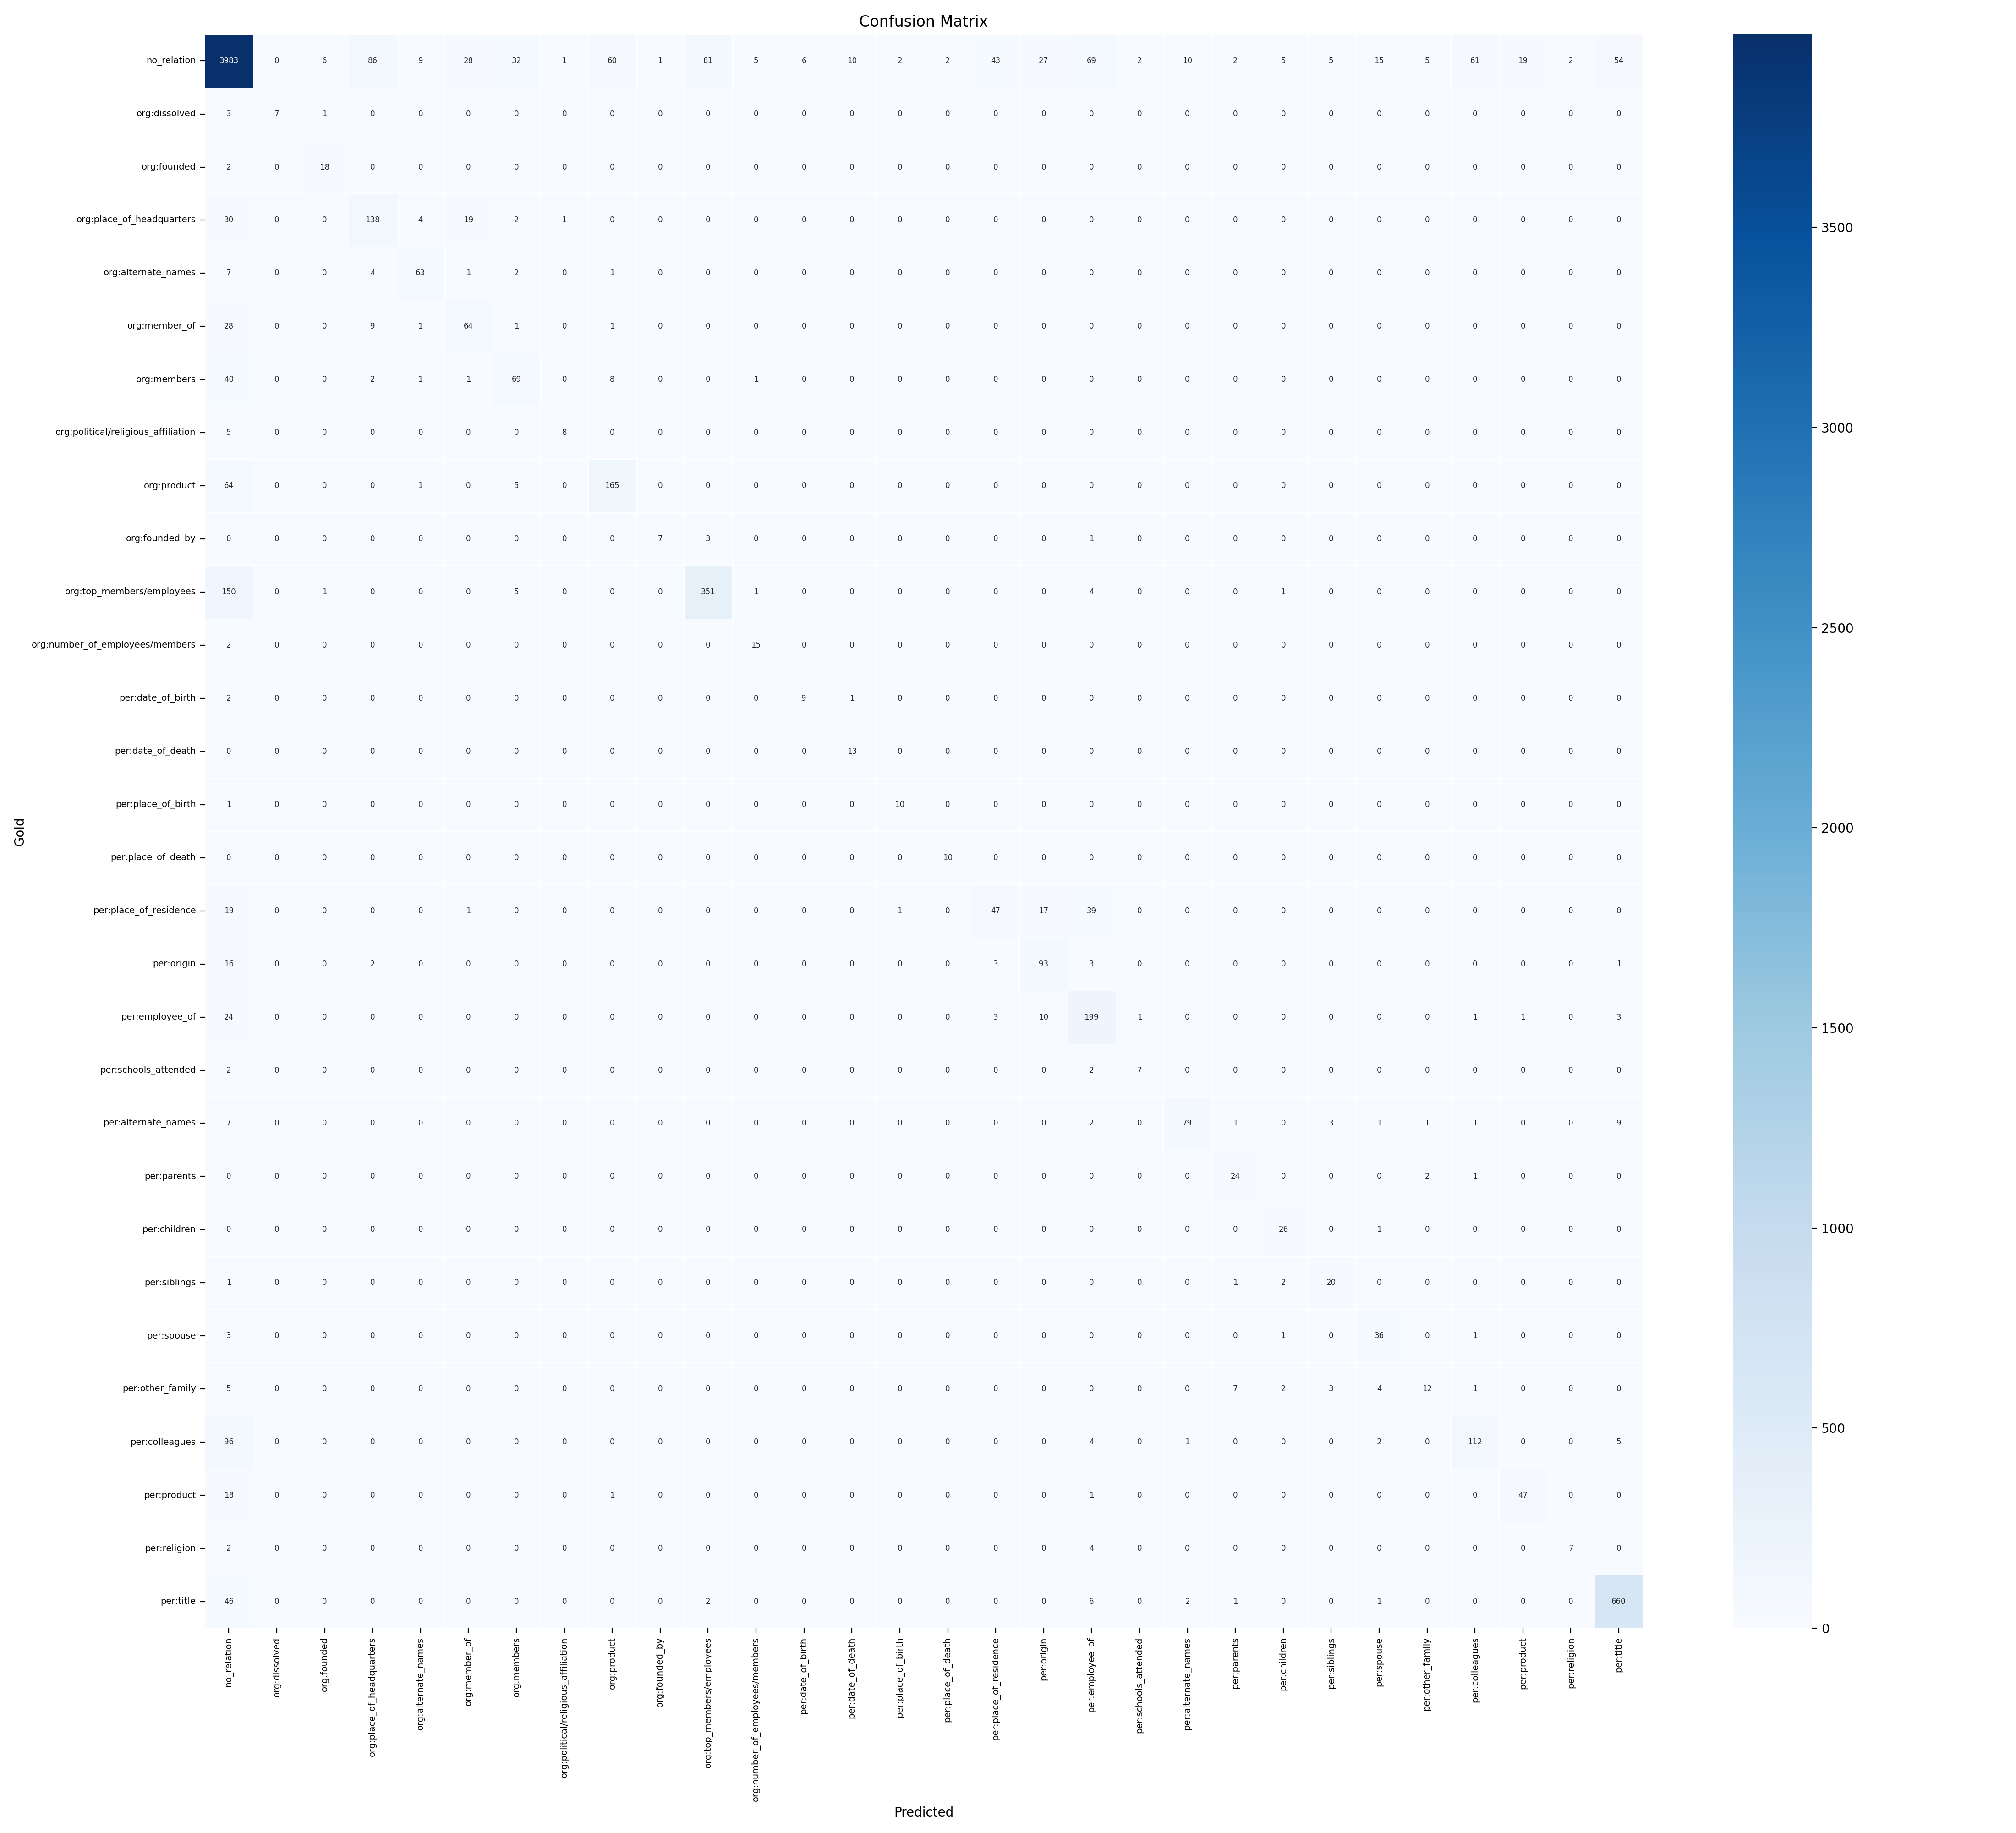

,no_relation,org:dissolved,org:founded,org:place_of_headquarters,org:alternate_names,org:member_of,org:members,org:political/religious_affiliation,org:product,org:founded_by,...,per:alternate_names,per:parents,per:children,per:siblings,per:spouse,per:other_family,per:colleagues,per:product,per:religion,per:title
no_relation,3983,0,6,86,9,28,32,1,60,1,...,10,2,5,5,15,5,61,19,2,54
org:dissolved,3,7,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
org:founded,2,0,18,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
org:place_of_headquarters,30,0,0,138,4,19,2,1,0,0,...,0,0,0,0,0,0,0,0,0,0
org:alternate_names,7,0,0,4,63,1,2,0,1,0,...,0,0,0,0,0,0,0,0,0,0
org:member_of,28,0,0,9,1,64,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
org:members,40,0,0,2,1,1,69,0,8,0,...,0,0,0,0,0,0,0,0,0,0
org:political/religious_affiliation,5,0,0,0,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
org:product,64,0,0,0,1,0,5,0,165,0,...,0,0,0,0,0,0,0,0,0,0
org:founded_by,0,0,0,0,0,0,0,0,0,7,...,0,0,0,0,0,0,0,0,0,0



[4] High-confidence wrong predictions


,sentence,subject,object,subject_type,object_type,gold_label_name,pred_label_name,confidence
0,함평군청소년상담복지센터·꿈드림에서 지난 12월 26일 제4차 실행위원회를 진행했다.,꿈드림,함평군청소년상담복지센터,ORG,ORG,org:alternate_names,no_relation,0.999951
1,인천에서 출생하였으며 지난날 한때 경기도 시흥에서 잠시 유아기를 보낸 적이 있는 그...,퓨리티,2014년,PER,DAT,org:dissolved,no_relation,0.999944
2,"또, 루벤스는 안트베르펜에 있는 도미니칸 교회에서 ""로자리오의 마돈나(Kunsthi...",루벤스,안트베르펜,PER,LOC,per:origin,no_relation,0.999928
3,"사태가 급박해지자, 창의사 김천일이 군사 3백 명을 거느리고 진주로 왔고, 충청병사...",황진,경상우병사,PER,POH,per:colleagues,no_relation,0.999913
4,"월간(月刊)중앙 WIN 기자, 월간(月刊)중앙 WIN 기획위원 등으로 활동하였고, ...",조선일보,기자,ORG,POH,org:top_members/employees,no_relation,0.999912
5,"이 강사는 녹색연합 기후에너지국장, 에너지기후정책연구소 연구기획위원을 역임하고, 현...",에너지기후정책연구소,이사,ORG,POH,org:top_members/employees,no_relation,0.999904
6,"전공은 계량정치학·정치과정론. 와세다 대학 정치경제학술원 교수, 오하이오 주립 대학...",오하이오 주립 대학교,교수,ORG,POH,org:top_members/employees,no_relation,0.999900
7,"위청은 공적으로 인해 3,800호를 받아 장평후에 봉해졌고, 휘하 교위인 소건과 장...",위청,평릉후,PER,POH,per:title,no_relation,0.999890
8,"히틀러유겐트 사단이 캐나다군 선봉 부대 일부를 압박해 3킬로미터 이상 후퇴시켰지만,...",캐나다군,노스 노바스코샤 하이랜더 연대,ORG,ORG,org:members,no_relation,0.999887
9,어려운 여건임에도 북구는 지난해 특별교부세 4억원을 들여 주거 취약계층 131세대를...,북구,55세대,ORG,NOH,org:top_members/employees,no_relation,0.999877


In [29]:
import subprocess
import sys
import pandas as pd
from IPython.display import display, Image

analysis_dir = ROOT / 'outputs' / 'architecture_entity_start' / 'error_analysis_test'
review_dir = ROOT / 'outputs' / 'performance_review'

required_analysis_files = [
    analysis_dir / 'label_scores.csv',
    analysis_dir / 'type_pair_scores.csv',
    analysis_dir / 'label_type_pair_scores.csv',
    analysis_dir / 'confusion_matrix.csv',
    analysis_dir / 'wrong_predictions.csv',
]

if all(path.exists() for path in required_analysis_files):
    print('[LOAD] Existing error analysis files found. Skip error_analysis.py.')
else:
    error_cmd = [
        sys.executable,
        str(ROOT / 'src' / 'error_analysis.py'),
        '--config', str(ROOT / 'configs' / 'model_roberta_large.yaml'),
        '--split', 'test',
        '--model_dir', str(ROOT / 'outputs' / 'architecture_entity_start'),
    ]
    print('[RUN] error_analysis.py')
    print(' '.join(error_cmd))
    subprocess.run(error_cmd, cwd=ROOT, check=True)

required_review_files = [
    review_dir / 'best_by_group.csv',
    review_dir / 'generalization_gap.csv',
    review_dir / 'model_efficiency.csv',
    review_dir / 'improvement_plan.csv',
]

if all(path.exists() for path in required_review_files):
    print('[LOAD] Existing performance review files found. Skip performance_review.py.')
else:
    review_cmd = [sys.executable, str(ROOT / 'src' / 'performance_review.py')]
    print('[RUN] performance_review.py')
    subprocess.run(review_cmd, cwd=ROOT, check=True)

# 1. Relation-level F1
print('\n[1] Relation F1 ascending')
relation_scores = pd.read_csv(analysis_dir / 'label_scores.csv')
if 'label_name' not in relation_scores.columns:
    if 'relation' in relation_scores.columns:
        relation_scores = relation_scores.rename(columns={'relation': 'label_name'})
    else:
        first_col = relation_scores.columns[0]
        relation_scores = relation_scores.rename(columns={first_col: 'label_name'})

relation_cols = ['label_name', 'precision', 'recall', 'f1-score', 'support']
relation_display = (
    relation_scores
    .dropna(subset=['f1-score'])
    .sort_values('f1-score', ascending=True)
    [[col for col in relation_cols if col in relation_scores.columns]].head(10)
)
display(relation_display)

# 2. Entity type pair performance
print('\n[2] Entity type pair performance')
type_pair_scores = pd.read_csv(analysis_dir / 'type_pair_scores.csv')
display(type_pair_scores.sort_values(['accuracy', 'total'], ascending=[True, False]))

# 3. Confusion matrix
print('\n[3] Confusion Matrix')
confusion_matrix_df = pd.read_csv(analysis_dir / 'confusion_matrix.csv', index_col=0)
confusion_matrix_img = analysis_dir / 'confusion_matrix.png'
if confusion_matrix_img.exists():
    display(Image(filename=str(confusion_matrix_img)))
else:
    print('confusion_matrix.png not found:', confusion_matrix_img)
display(confusion_matrix_df)

# 4. Wrong predictions
print('\n[4] High-confidence wrong predictions')
wrong_predictions = pd.read_csv(analysis_dir / 'wrong_predictions.csv')
wrong_cols = [
    'sentence', 'subject', 'object', 'subject_type', 'object_type',
    'gold_label_name', 'pred_label_name', 'confidence'
]
display(wrong_predictions.sort_values('confidence', ascending=False)[[col for col in wrong_cols if col in wrong_predictions.columns]].head(30))

### **성능 검토 결과**

**[1] Relation별 F1 분석**
- `per:place_of_residence`, `per:other_family`, `per:colleagues`, `org:members`, `org:member_of` 등에서 F1이 낮게 나타남
- 다만 f1 하위 10개 확인 결과, support와 f1 간의 연관성은 적은 것으로 판단됨.
- support 보다 relation 의미가 모호하거나 `no_relation` 데이터 편향으로 발생한 것으로 유추됨


**[2] Entity Type Pair별 성능 분석**
- 전반적으로 0.7 정도 이상(1위 제외)의 accuracy인 것을 통해, entity type 차이가 정확도에 큰 영향을 주는 것 같지 않음
- PER-LOC, ORG-LOC, PER-PER 조합에서 상대적으로 낮은 정확도 보임


**[3] Confusion Matrix & [4] 오답 사례 분석**
- `no_relation`으로 예측하는 사례가 다수 확인됨
- 높은 confidence로 틀린 오답도 많으며, 상위 30개 중 2개 제외하고 모두 no_relation으로 잘못 예측함

### **성능개선 Insight**

- **`Insight 3` - `Weighted Cross Entropy`: loss*class_weight, 적은 relation 학습 강화**
- **`Insight 4` - `threshold 조정`, `no_relation` 편향 완화**
- **`Insight 5` - `calibration 검토(confidence 재보정)`, `no_relation` 편향 완화**
- **`Insight 6` - `candidate filtering`, 특정 type pair에서 반복적으로 발생하는 오류 relation 경쟁 완화**

## **7) 성능 개선**

- 모델 선정 및 성능 검토 결과를 바탕으로 성능 개선 실험 수행

- 주요 개선 목표

    - `no_relation` 편향 완화

    - relation 구분 성능 개선

    - 높은 confidence 오답 감소



**우선 적용 (실험 수행)**


- **Weighted Cross Entropy (Insight 3)**: relation별 학습 균형 조정 필요

    - 실험 방법
    
        - train label frequency 기반 class weight 적용
    
        - baseline 대비 `test_micro_f1`, `test_auprc` 비교


- **Threshold 조정 (Insight 4)**: `no_relation` 편향 완화

    - 탐색 범위: `0.50 ~ 0.90`
    - 간격: `0.05`
    - 확인 지표: `val_micro_f1`, `test_micro_f1`, `test_auprc`

- **Calibration (Temperature Scaling) (Insight 5)**: confidence 재보정 필요

    - 탐색 범위: `1.0 ~ 3.0`
    - 간격: `0.2`
    - 확인 지표: validation NLL, `test_micro_f1`, `test_auprc`


**선택 적용 (시간 여유 시 수행)**


- **Ensemble (Insight 1)**: 모델별 강점을 결합하여 추가 성능 향상 가능성 검토

    - 실험 방법
    
        - `roberta-large + roberta-base (+ bert-base)` soft voting 비교
    
        - LUKE-large 제외
 


- **Candidate Filtering (Insight 6)**: 일부 type pair에서 relation 경쟁으로 인한 성능 저하 가능성 확인

    - 실험 방법
    
        - type pair 기반 relation 후보 제한 후 비교

In [30]:
# 1. Weighted Cross Entropy 실험

weighted_ce_cmd = [
    sys.executable,
    str(ROOT / 'src' / 'improvement_experiments.py'),
    '--mode', 'weighted_ce',
    '--weighted-config', str(ROOT / 'configs' / 'improvement_weighted_ce_roberta_large.yaml'),
    '--output-csv', str(ROOT / 'outputs' / 'improvement_experiments.csv'),
]

print('[Weighted Cross Entropy 실행 명령어]')
print(' '.join(map(str, weighted_ce_cmd)))

# GPU 시간이 있을 때만 실행
# subprocess.run(weighted_ce_cmd, cwd=ROOT, check=True)

[Weighted Cross Entropy 실행 명령어]
c:\Users\gyr\anaconda3\envs\klue-re\python.exe C:\Users\gyr\Downloads\NaverBoostcamp-KLUE-RE-competition-main\NaverBoostcamp-KLUE-RE-competition-main\src\improvement_experiments.py --mode weighted_ce --weighted-config C:\Users\gyr\Downloads\NaverBoostcamp-KLUE-RE-competition-main\NaverBoostcamp-KLUE-RE-competition-main\configs\improvement_weighted_ce_roberta_large.yaml --output-csv C:\Users\gyr\Downloads\NaverBoostcamp-KLUE-RE-competition-main\NaverBoostcamp-KLUE-RE-competition-main\outputs\improvement_experiments.csv


Required postprocess improvement experiments already exist. Skip execution.


,experiment_name,val_micro_f1,val_auprc,test_micro_f1,test_auprc,threshold,temperature,note
0,baseline_roberta_large,86.034000,84.383554,73.036897,77.264496,None,None,Baseline: roberta-large + entity_start before ...
2,improvement_temperature_calibration,86.015491,83.277662,73.025382,77.661234,NaN,1.6,Best temperature on val NLL: 1.6
1,improvement_threshold_tuning,86.882682,84.377326,72.758210,77.250445,0.75,NaN,Best relation threshold on val: 0.75
3,improvement_weighted_ce,84.398458,83.836128,67.944910,76.972834,NaN,NaN,Weighted Cross Entropy with final input format...


,threshold,val_micro_f1,val_macro_f1,val_accuracy,test_micro_f1,test_macro_f1,test_accuracy,test_auprc
0,0.50,86.215105,78.727635,84.416384,73.219691,71.434591,81.365100,77.250445
1,0.55,86.448802,79.038843,84.539575,73.402195,71.445534,81.532518,77.250445
2,0.60,86.659365,79.887371,84.693563,73.271211,71.391199,81.493883,77.250445
3,0.65,86.690172,79.833601,84.601170,73.154585,71.152188,81.532518,77.250445
4,0.70,86.869585,80.368488,84.693563,73.090482,70.753147,81.584031,77.250445
5,0.75,86.882682,80.233432,84.601170,72.758210,70.732048,81.493883,77.250445
6,0.80,86.788206,79.527538,84.293194,72.393488,69.813105,81.403735,77.250445
7,0.85,86.350216,79.373098,83.738836,71.734135,69.081143,81.249195,77.250445
8,0.90,86.101539,78.439886,83.338466,70.238746,67.428675,80.605280,77.250445


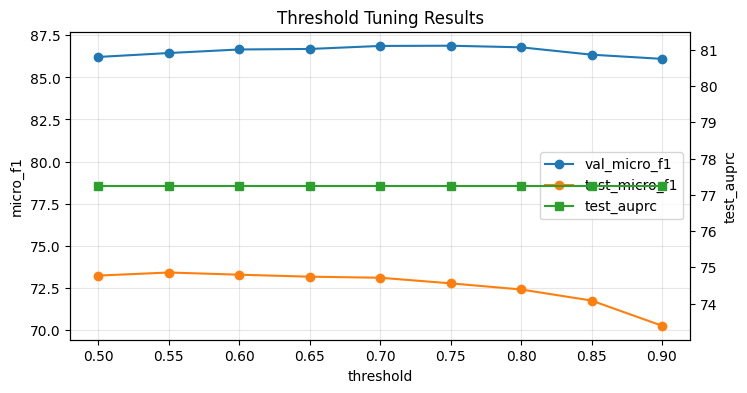

,temperature,val_nll,val_micro_f1,val_macro_f1,val_accuracy,test_micro_f1,test_macro_f1,test_accuracy,test_auprc
0,1.0,0.674012,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.250445
1,1.2,0.589801,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.311413
2,1.4,0.541931,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.507409
3,1.6,0.521792,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.661234
4,1.8,0.524847,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.592634
5,2.0,0.547830,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.496238
6,2.2,0.587655,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.500074
7,2.4,0.641128,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.493180
8,2.6,0.705037,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.290571
9,2.8,0.776349,86.015491,78.777253,84.323991,73.025382,71.158439,81.120412,77.301627


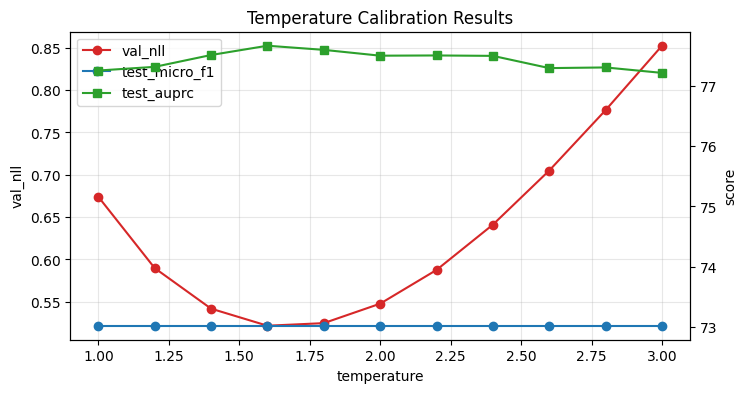

In [31]:
import subprocess

import matplotlib.pyplot as plt

# 2. Run threshold tuning / temperature calibration experiments.
improvement_path = ROOT / 'outputs' / 'improvement_experiments.csv'
detail_dir = ROOT / 'outputs' / 'improvement_details'
threshold_grid_path = detail_dir / 'threshold_grid.csv'
calibration_grid_path = detail_dir / 'calibration_grid.csv'
active_improvement_experiments = [
    'improvement_threshold_tuning',
    'improvement_temperature_calibration',
]

# Skip execution only when summary rows and grid detail files both exist.
need_run = True
if improvement_path.exists() and threshold_grid_path.exists() and calibration_grid_path.exists():
    existing_improvement = pd.read_csv(improvement_path)
    if 'experiment_name' in existing_improvement.columns:
        done = set(existing_improvement['experiment_name'].astype(str))
        need_run = not set(active_improvement_experiments).issubset(done)

if need_run:
    improvement_cmd = [
        sys.executable, str(ROOT / 'src' / 'improvement_experiments.py'),
        '--mode', 'postprocess',
        '--config', str(ROOT / 'configs' / 'model_roberta_large.yaml'),
        '--model-dir', str(ROOT / 'outputs' / 'architecture_entity_start'),
        '--output-csv', str(improvement_path),
    ]
    subprocess.run(improvement_cmd, cwd=ROOT, check=True)
else:
    print('Required postprocess improvement experiments already exist. Skip execution.')

# 3. Display baseline and improvement results together.
# Baseline condition:
# - klue/roberta-large
# - typed_entity_marker_punct_question
# - detailed_stratified
# - entity_start
baseline_sources = [
    ROOT / 'outputs' / 'architecture_experiments.csv',
    ROOT / 'outputs' / 'model_experiments.csv',
]
baseline_candidates = []
for baseline_path in baseline_sources:
    if baseline_path.exists():
        baseline_df = pd.read_csv(baseline_path)
        if 'experiment_name' not in baseline_df.columns:
            continue
        if baseline_path.name == 'architecture_experiments.csv':
            baseline_row = baseline_df[baseline_df['experiment_name'].astype(str).eq('architecture_entity_start')].copy()
        else:
            baseline_row = baseline_df[baseline_df['experiment_name'].astype(str).eq('model_roberta_large')].copy()
        if len(baseline_row) > 0:
            baseline_candidates.append(baseline_row.tail(1))

if baseline_candidates:
    baseline_result = pd.concat(baseline_candidates, ignore_index=True).head(1)
    baseline_result['experiment_name'] = 'baseline_roberta_large'
    baseline_result['threshold'] = None
    baseline_result['temperature'] = None
    baseline_result['note'] = 'Baseline: roberta-large + entity_start before threshold/calibration'
else:
    baseline_result = pd.DataFrame()

improvement_results = pd.read_csv(improvement_path)
improvement_results = improvement_results[
    improvement_results['experiment_name'].isin(active_improvement_experiments + ['improvement_weighted_ce'])
].copy()

comparison_results = pd.concat([baseline_result, improvement_results], ignore_index=True)
display_cols = [
    'experiment_name',
    'val_micro_f1', 'val_auprc', 'test_micro_f1', 'test_auprc',
    'threshold', 'temperature', 'note'
]
for col in display_cols:
    if col not in comparison_results.columns:
        comparison_results[col] = None

display(comparison_results[display_cols].sort_values('test_micro_f1', ascending=False, na_position='last'))

# 4. Visualize grid search results.
if threshold_grid_path.exists():
    threshold_grid = pd.read_csv(threshold_grid_path)
    display(threshold_grid)
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(threshold_grid['threshold'], threshold_grid['val_micro_f1'], marker='o', label='val_micro_f1')
    ax1.plot(threshold_grid['threshold'], threshold_grid['test_micro_f1'], marker='o', label='test_micro_f1')
    ax1.set_xlabel('threshold')
    ax1.set_ylabel('micro_f1')
    ax1.grid(alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(threshold_grid['threshold'], threshold_grid['test_auprc'], marker='s', color='tab:green', label='test_auprc')
    ax2.set_ylabel('test_auprc')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.title('Threshold Tuning Results')
    plt.show()
else:
    print('threshold_grid.csv not found.')

if calibration_grid_path.exists():
    calibration_grid = pd.read_csv(calibration_grid_path)
    display(calibration_grid)
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(calibration_grid['temperature'], calibration_grid['val_nll'], marker='o', color='tab:red', label='val_nll')
    ax1.set_xlabel('temperature')
    ax1.set_ylabel('val_nll')
    ax1.grid(alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(calibration_grid['temperature'], calibration_grid['test_micro_f1'], marker='o', label='test_micro_f1')
    ax2.plot(calibration_grid['temperature'], calibration_grid['test_auprc'], marker='s', color='tab:green', label='test_auprc')
    ax2.set_ylabel('score')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.title('Temperature Calibration Results')
    plt.show()
else:
    print('calibration_grid.csv not found.')



### **성능 개선 결과**

- **`Weighted Cross Entropy`**
    
    - validation 성능(`86.03 → 84.40`)과 test 성능(`73.04 → 67.94`)이 모두 감소함
    
    - 단순 class weight 적용은 오히려 일반화 성능을 저하시킨 것으로 확인됨
    
    - 현재 설정에서는 loss 기반 불균형 보정 효과는 제한적인 것으로 판단함
 


- **`Threshold tuning` (threshold best: 0.75)**

    - 최종 예측 기준(decision boundary)을 조정하는 후처리 방식이므로, validation `micro_f1` 기준으로 최적 threshold를 선택하였음  

    - 다만 validation 성능은 향상되었으나(`86.03 → 86.88`), test 성능 개선으로 이어지지 않았음(`73.04 → 72.76`)

    - threshold 기반 후처리 효과는 제한적인 것으로 판단함


- **`Temperature calibration` (temperature best: 1.6)**

    - confidence 재보정이므로, confidence 품질을 직접 반영하는 validation `NLL` 최소 기준으로 최적 temperature를 선택하였음  

    - test `micro_f1` 변화는 제한적이었으나(`73.04 → 73.03`), test `AUPRC`는 향상됨(`77.26 → 77.66`)
    
    - temperature가 test AUPRC 향상으로 이어져 calibration 목적과 일관된 결과를 확인함

## **8) 최종 실험 결과 및 결론**

### **8.1) 최종 실험 결과**
| 구분 | 최종 선택 | 선택 기준 |
|---|---|---|
| Data Split | `detailed_stratified` | test 성능 및 macro_f1 기준 가장 안정적 |
| Input Format | `typed_entity_marker_punct_question` | marker + type + question 조합에서 최고 성능 |
| Architecture | `entity_start` | test_micro_f1 최고 |
| PLM | `klue/roberta-large` | test_micro_f1, test_auprc 최고 |
| 성능 개선 | `Temperature Calibration (T=1.6)` | 추가 학습 없이 test_auprc 향상 |

---

### **최종 모델 구성**

- **Split**
    
    `detailed_stratified`

- **Input**
    
    `typed_entity_marker_punct_question`

- **Architecture**
    
    `entity_start`
    
    (CLS + subject/object start representation)

- **PLM**
    
    `klue/roberta-large`

- **Post-processing**
    
    `Temperature Calibration (T=1.6)`

---

### **최종 성능**

| 조건 | test_micro_f1 | test_auprc |
|---|---:|---:|
| Baseline | `73.04` | `77.26` |
| + Threshold tuning | `72.76` | `77.25` |
| + Temperature Calibration | `73.03` | `77.66` |

→ 최종적으로 **Temperature Calibration 적용 모델**을 최종 결과로 선정함.

---

### **최종 결론**

- RE에서는 **entity 정보를 입력에 어떻게 표현하는지(Input Representation)** 가 성능에 더 큰 영향을 미쳤음
- entity 정보를 직접 활용하는 구조(`[CLS + entity_start], [CLS + entity_start + entity_end]`)가 `[CLS]` 기반 구조보다 효과적이었음
- 본 실험의 아키텍처 구조와 입력 프롬프트 기준, `roberta-large`가 성능과 안정성 측면에서 가장 우수한 결과를 보였음
- 오류 분석 결과, 성능 제한 요인은 데이터 수 자체보다 **`no_relation` 편향 및 confidence 문제**로 확인됨
- 추가 학습 없이도 **calibration 기반 후처리만으로 ranking 품질(AUPRC) 개선 가능성**을 확인함

## **9) 회고**

### **배운 점 / 잘 수행한 점**
- Relation Extraction Task와 KLUE 데이터셋에 대한 이해도를 높일 수 있었다.
- EDA 과정을 수행하면서 다양하게 데이터를 시각화하고 분석하는 방법을 익힐 수 있었고, 이를 실험 방향 결정에 활용한 점이 잘했다고 생각한다.
- 논문을 조사하며, 새로운 접근법과 성능 개선 방법 도출 과정을 확인할 수 있었다. 이를 기반으로 구조 설계, 모델 선정 가설을 설정한 것도 좋았다.
- 각 과정을 근거있게 수행하기 위해 철저한 조사와 이해에 중점을 둔 점이 잘한점이라고 생각한다.

### **어려웠던 점 / 한계 / 아쉬운 점**
- 데이터 불균형을 확인하였지만, 새로운 데이터 증강 기법을 고민하고 이를 시도해보지 못한 점이 아쉽다.
- 본 실험에서 단일 아키텍처 구조로만 수행하여, 다양한 구조 및 모델을 충분히 시도하고 비교하지 못한 점이 아쉽다.
- 참고했던 프로젝트 대비 중간 성능 산출물들이 비교적 낮은 점수를 보인 것에 대해, 더 세부적인 원인 분석과 차이점을 파악하지 못한 것이 아쉽다.

### **다음에 시도해보고 싶은 것**
- 최근 GPT, Gemini 등 대규모 언어모델의 추론 성능이 크게 향상된 만큼, Prompt 기반 Relation Extraction 및 Instruction Tuning 기반 접근도 비교해보고 싶다.
- `3.3`에 정리한 향후 적용 가능한 증강 기법을 실제로 적용하여 데이터 불균형 문제 개선 여부를 검증해보고 싶다.
- 다양한 아키텍처 구조를 시도해서 선행 연구에서 좋은 성능을 보인 모델(LUKE, T5 등)을 실험하고 싶다.
- KLUE와 같이 정제된 데이터가 아닌, 추후 비정형 텍스트(문서, 영상 등)에서 직접 데이터를 추출 및 변환하여 관계 정보 추출, 지식 그래프로 연결하는 파이프라인으로 확장도 고려해보면 좋을 것 같다.

## **Reference**

### Implementation Reference
[1] Boostcamp AI Tech Team 10, *KLUE Relation Extraction Project Repository*, GitHub.  
Available: https://github.com/boostcampaitech6/level2-klue-nlp-10

[2] Boostcamp AI Tech Team 09, *KLUE Relation Extraction Project Repository*, GitHub.  
Available: https://github.com/boostcampaitech3/level2-klue-level2-nlp-09

[3] Yeonwoo Sung, *KLUE Entity Relation Extraction Repository*, GitHub.  
Available: https://github.com/YeonwooSung/Klue_EntityRelation

[4] Cheonggyemountain Sherpa, *KLUE Relation Extraction Competition Review and Experiments*, Blog.  
Available: https://cheonggyemountain-sherpa.github.io/KLUE_RE/


### Relation Extraction Papers
[5] L. B. Soares, N. FitzGerald, J. Ling, and T. Kwiatkowski,  
*Matching the Blanks: Distributional Similarity for Relation Learning*, 2019. 

[6] W. Zhou and M. Chen,  
*An Improved Baseline for Sentence-level Relation Extraction*, 2022.  

[7] J. Zheng and Z. Chen,  
*Sentence-Level Relation Extraction via Contrastive Learning with Descriptive Relation Prompts*, 2023. 

[8] X. Zhao et al.,  
*A Comprehensive Survey on Relation Extraction: Recent Advances and New Frontiers*, 2024.  

[9] P. He, X. Liu, J. Gao, and W. Chen,  

[10] I. Yamada, A. Asai, H. Shindo, H. Takeda, and Y. Matsumoto,  
*LUKE: Deep Contextualized Entity Representations with Entity-aware Self-attention*, 2020.